# **quick**start

The **quickbrain** provides fast, lightweight whole-brain surface plotting with a single function call.
Unlike most neuroimaging visualisation packages, the built-in MNI152 meshes include the
**cerebellum and brainstem**, giving you a complete overview of brain-wide statistical maps.

## Installation

```bash
pip install "quickbrain @ git+https://github.com/pni-lab/quickbrain.git"
```

:::{note}
:label: quick-example
PyPI package coming soon!
:::

## Import

Let's import the main function `plot_brain` from the `quickbrain` package.

In [1]:
from quickbrain import plot_brain

## 1. Quickstart

With no arguments, `plot_brain()` renders the left pial surface with a
signed-curvature background — gyri and sulci are immediately visible.
The mesh covers the full hemisphere **including the cerebellum**.

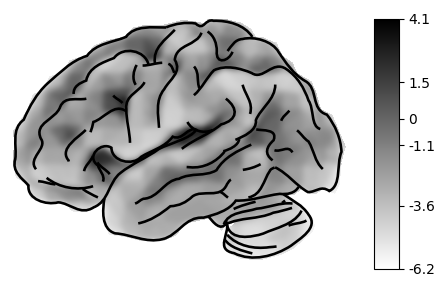

In [2]:
plot_brain()

Now we load a statistical map to plot in our examples (in this case meta-analysis of pain responses from [Zunhammer et al., 2021](https://www.nature.com/articles/s41467-021-21179-3)).

In [3]:
from quickbrain import load_example_image

pain_response = load_example_image("pain_response")

Pass this to the `plot_brain` function to plot it.

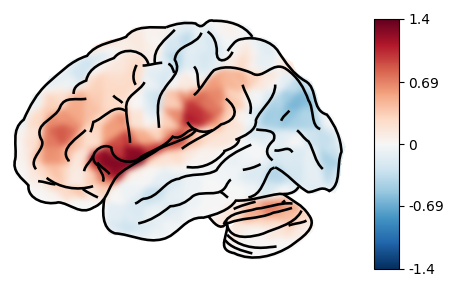

In [4]:
#| label: ex

plot_brain(pain_response)

By default, the lateral view of the pial surface of the left hemisphere is plotted.
We can change this by passing the following parameters:
- `hemi`: `"left"` or `"right"` hemisphere (default: `"left"`)
- `view`: `"lateral"` or `"medial"` view (default: `"lateral"`)
- `surf_type`: `"pial"` or `"inflated"` surface type (default: `"pial"`)
- `threshold`: the threshold to apply to the statistical map (default: `0.0`)
- `cmap`: the colormap to use (default: `"coolwarm"`)
- `colorbar`: whether to show the colorbar (default: `True`)

Let's plot the right hemisphere in the medial view with an inflated surface, thresholded at 0.4.

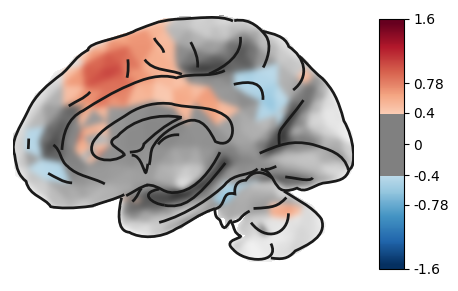

In [5]:
plot_brain(pain_response, threshold=0.4, surf_type='inflated', hemi='right', view='medial')

## 2. Composite plots

`quickbrain` is fast. So you can plot large composite images, without having to wait a lot for the rendering.
To do so, you can use `matplotlib`'s `subplots` to create a grid of plots, and then pass each plot to `plot_brain`.
Ideal for visualization during analyses, but also useful for creating overview plots for publications.



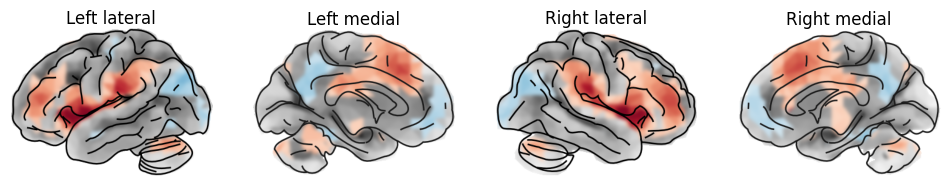

In [6]:
import matplotlib.pyplot as plt

_threshold = 0.3    
fig, ax = plt.subplots(1, 4, figsize=(12,10), subplot_kw={"projection": "3d"})
plot_brain(pain_response, hemi='left', view='lateral', threshold=_threshold, axes=ax[0], colorbar=False, title="Left lateral")
plot_brain(pain_response, hemi='left', view='medial', threshold=_threshold, axes=ax[1], colorbar=False, title="Left medial" )
plot_brain(pain_response, hemi='right', view='lateral', threshold=_threshold, axes=ax[2], colorbar=False, title="Right lateral")
plot_brain(pain_response, hemi='right', view='medial', threshold=_threshold, axes=ax[3], colorbar=False, title="Right medial")
plt.show()      

This type of visualization can be useful to show whole brain patterns, e.g. effect sizes, without any thresholding.

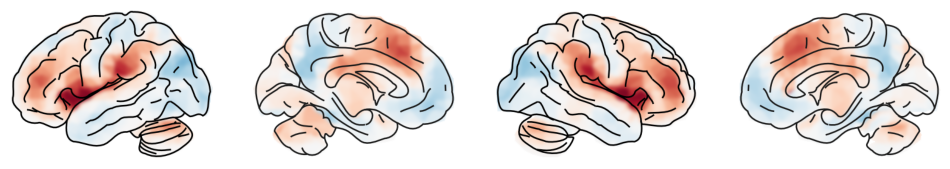

In [7]:
#| label: nice-brains

_threshold = 0    
fig, ax = plt.subplots(1, 4, figsize=(12,10), subplot_kw={"projection": "3d"})
plot_brain(pain_response, hemi='left', view='lateral', threshold=_threshold, axes=ax[0], colorbar=False)
plot_brain(pain_response, hemi='left', view='medial', threshold=_threshold, axes=ax[1], colorbar=False)
plot_brain(pain_response, hemi='right', view='lateral', threshold=_threshold, axes=ax[2], colorbar=False)
plot_brain(pain_response, hemi='right', view='medial', threshold=_threshold, axes=ax[3], colorbar=False)
plt.show()      

Let's apply a different style: with a blue-red colormap, thresholded at 0.5, but without the grayscale curvature map, to preserve the clean look, but draw attention to the super-threshold blobs.

/var/folders/rc/b4064_3d4dj60wt9y_447fyr0000gn/T/ipykernel_47568/4048287829.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


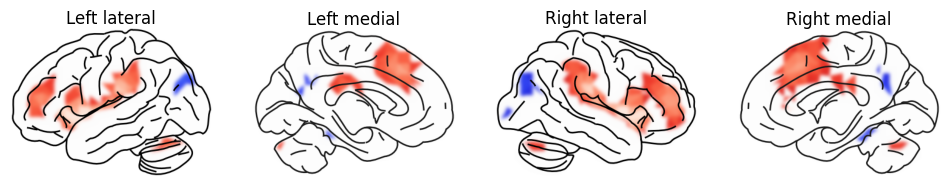

In [8]:
import matplotlib.pyplot as plt

_threshold = 0.5    
fig, ax = plt.subplots(1, 4, figsize=(12,10), subplot_kw={"projection": "3d"})
plot_brain(pain_response, hemi='left', view='lateral', threshold=_threshold, axes=ax[0], cmap='blue_red', colorbar=False, bg_map=0.01, title="Left lateral")
plot_brain(pain_response, hemi='left', view='medial', threshold=_threshold, axes=ax[1], cmap='blue_red', colorbar=False,  bg_map=0.01, title="Left medial" )
plot_brain(pain_response, hemi='right', view='lateral', threshold=_threshold, axes=ax[2], cmap='blue_red', colorbar=False, bg_map=0.01, title="Right lateral")
plot_brain(pain_response, hemi='right', view='medial', threshold=_threshold, axes=ax[3], cmap='blue_red', colorbar=False, bg_map=0.01, title="Right medial")
plt.tight_layout()
plt.show()      

On the medial view, we can also see the hippocampus and - with the correct sampling parameters (see later) - signal fromall the subcortical structures.

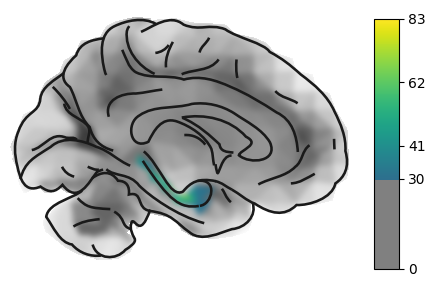

In [9]:
hip = load_example_image("left_hippocampus")

plot_brain(hip, view='medial', threshold=30, cmap='viridis')

## 3. Inflated surfaces

With the `surf_type` parameter, we can switch between the pial and inflated surfaces. The inflated surface provides a better view of deep sulcal structure, for instance the insula.

/var/folders/rc/b4064_3d4dj60wt9y_447fyr0000gn/T/ipykernel_47568/659833036.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


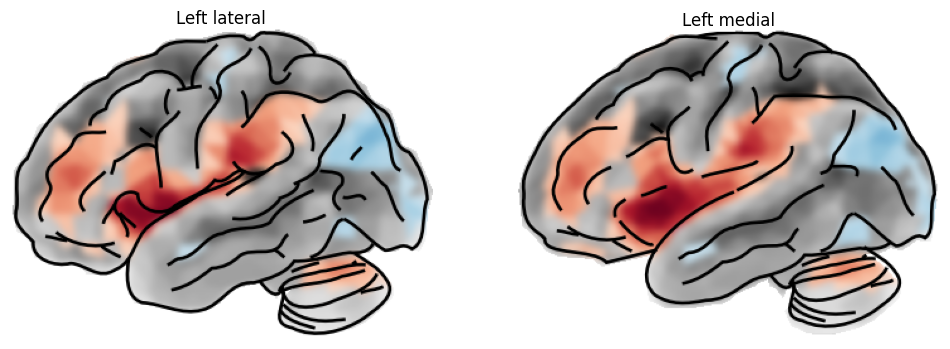

In [10]:
import matplotlib.pyplot as plt

_threshold = 0.3    
fig, ax = plt.subplots(1, 2, figsize=(12,10), subplot_kw={"projection": "3d"})
plot_brain(pain_response, hemi='left', view='lateral', surf_type='pial', threshold=_threshold, axes=ax[0], colorbar=False, title="Left lateral")
plot_brain(pain_response, hemi='left', view='lateral', surf_type='inflated', threshold=_threshold, axes=ax[1], colorbar=False, title="Left medial" )
plt.tight_layout()
plt.show()   

Let's plot some more varieties.

/var/folders/rc/b4064_3d4dj60wt9y_447fyr0000gn/T/ipykernel_47568/772067111.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


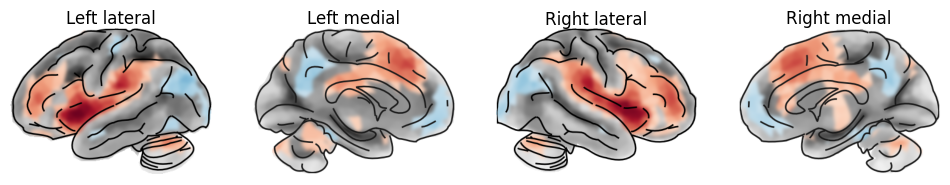

In [11]:
import matplotlib.pyplot as plt

_threshold = 0.3    
fig, ax = plt.subplots(1, 4, figsize=(12,10), subplot_kw={"projection": "3d"})
plot_brain(pain_response, hemi='left', view='lateral', surf_type='inflated', threshold=_threshold, axes=ax[0], colorbar=False, title="Left lateral")
plot_brain(pain_response, hemi='left', view='medial', surf_type='inflated', threshold=_threshold, axes=ax[1], colorbar=False, title="Left medial" )
plot_brain(pain_response, hemi='right', view='lateral', surf_type='inflated', threshold=_threshold, axes=ax[2], colorbar=False, title="Right lateral")
plot_brain(pain_response, hemi='right', view='medial', surf_type='inflated', threshold=_threshold, axes=ax[3], colorbar=False, title="Right medial")
plt.tight_layout()
plt.show()      

/var/folders/rc/b4064_3d4dj60wt9y_447fyr0000gn/T/ipykernel_47568/3675095081.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


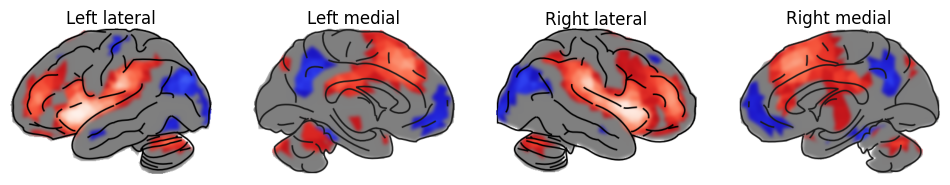

In [12]:
import matplotlib.pyplot as plt

_threshold = 0.3    
fig, ax = plt.subplots(1, 4, figsize=(12,10), subplot_kw={"projection": "3d"})
plot_brain(pain_response, hemi='left', view='lateral', surf_type='inflated', threshold=_threshold, axes=ax[0], bg_map=0.5, colorbar=False, title="Left lateral", cmap='blue_red')
plot_brain(pain_response, hemi='left', view='medial', surf_type='inflated', threshold=_threshold, axes=ax[1], bg_map=0.5, colorbar=False, title="Left medial", cmap='blue_red' )
plot_brain(pain_response, hemi='right', view='lateral', surf_type='inflated', threshold=_threshold, axes=ax[2], bg_map=0.5, colorbar=False, title="Right lateral", cmap='blue_red')
plot_brain(pain_response, hemi='right', view='medial', surf_type='inflated', threshold=_threshold, axes=ax[3], bg_map=0.5, colorbar=False, title="Right medial", cmap='blue_red')
plt.tight_layout()
plt.show()      

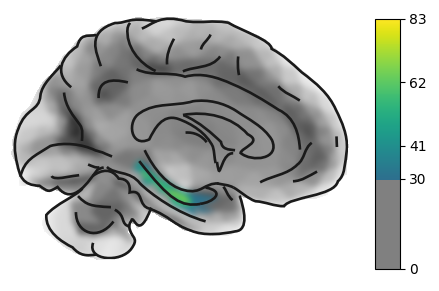

In [13]:
hip = load_example_image("left_hippocampus")

plot_brain(hip, view='medial', threshold=30, cmap='viridis', surf_type='inflated')

## 4. Advanced options

The `bg_map` parameter controls the underlay:

| value | effect |
|---|---|
| `"curvature"` (default) | signed curvature — highlights gyri/sulci |
| a float, e.g. `0.5` | uniform grey |
| `None` | no background (white) |

/var/folders/rc/b4064_3d4dj60wt9y_447fyr0000gn/T/ipykernel_47568/1115284430.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


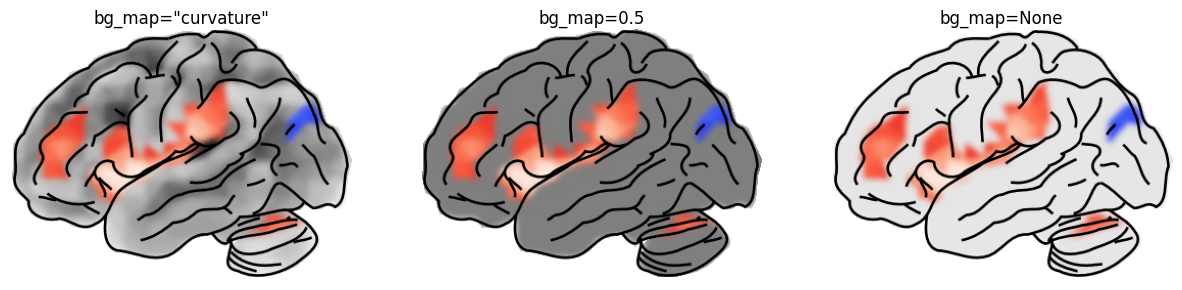

In [14]:
fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3,
    figsize=(15, 5),
    subplot_kw={"projection": "3d"},
)

for ax, bg, label in [
    (ax1, "curvature", 'bg_map="curvature"'),
    (ax2, 0.5, "bg_map=0.5"),
    (ax3, 0.1, "bg_map=None"),
]:
    plot_brain(
        pain_response,
        bg_map=bg,
        threshold=0.5,
        axes=ax,
        colorbar=False,
        title=label,
        cmap='blue_red',
    )

plt.tight_layout()
plt.show()

`background="transparent"` turns the white canvas transparent (useful for
compositing into posters or slides).  Only two values are allowed:
`"white"` (default) and `"transparent"`.

**Note: this feature is under development and may not work as expected.**

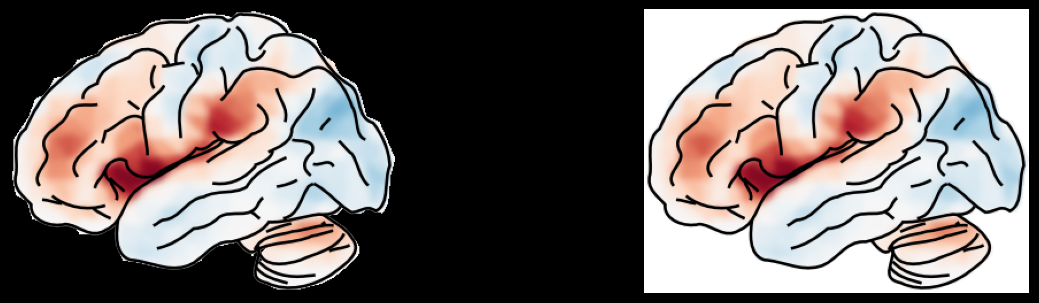

In [15]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(15, 5),
    subplot_kw={"projection": "3d"},
)

# set plot canvas background to black
fig.patch.set_facecolor('black')



plot_brain(pain_response, background="transparent", axes=ax1, colorbar=False)
plot_brain(pain_response, background="white", axes=ax2, colorbar=False)
plt.show()

We can also costume or hide the overlay contours.

/var/folders/rc/b4064_3d4dj60wt9y_447fyr0000gn/T/ipykernel_47568/1748492978.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


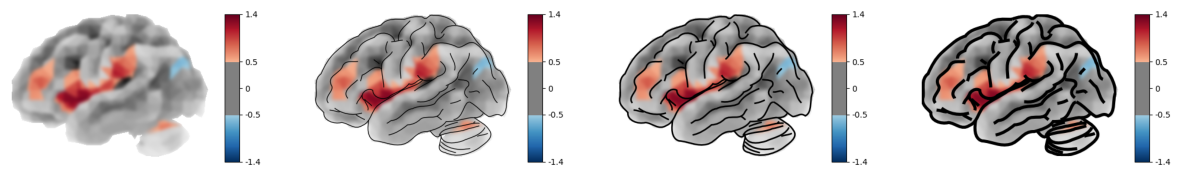

In [16]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(
    1, 4,
    figsize=(15, 5),
    subplot_kw={"projection": "3d"},
)

plot_brain(pain_response, threshold=0.5, axes=ax1, overlay=None)
plot_brain(pain_response, threshold=0.5, axes=ax2, overlay_linewidth=0.5)
plot_brain(pain_response, threshold=0.5, axes=ax3, overlay_linewidth=1)
plot_brain(pain_response, threshold=0.5, axes=ax4, overlay_linewidth=2)
plt.tight_layout()
plt.show()

`post_blur` (default 3 px) applies a light Gaussian blur to the brain
rendering *before* the SVG overlay is composited.  This softens the
polygon edges.  Set to `0` to disable.

**In most cases the default blur is fine.**

/var/folders/rc/b4064_3d4dj60wt9y_447fyr0000gn/T/ipykernel_47568/1741876256.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


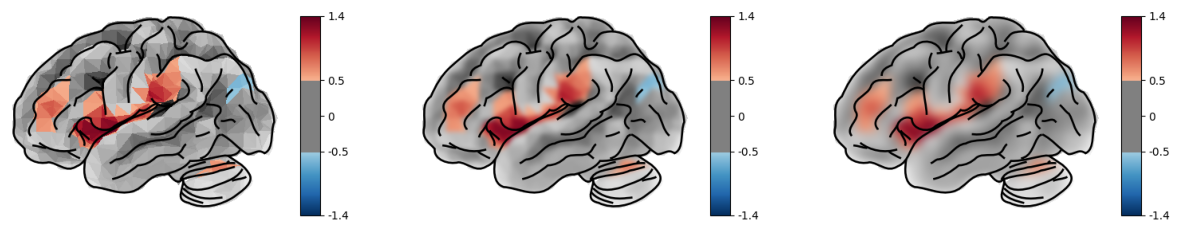

In [17]:
fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3,
    figsize=(15, 5),
    subplot_kw={"projection": "3d"},
)

plot_brain(pain_response, threshold=0.5, axes=ax1, post_blur=0)
plot_brain(pain_response, threshold=0.5, axes=ax2, post_blur=3)
plot_brain(pain_response, threshold=0.5, axes=ax3, post_blur=6)
plt.tight_layout()
plt.show()

## 5. Saving to file

Use `output_file` to write the figure directly (any format matplotlib
supports: png, pdf, svg, ...).

In [18]:
plot_brain(
    pain_response,
    threshold=0.5,
    hemi="right",
    view="medial",
    title="Right medial",
    output_file="/tmp/quickbrain_demo.png",
    overlay=None,
)
print("Saved to /tmp/quickbrain_demo.png")

Saved to /tmp/quickbrain_demo.png
